# Phase 7c-v2: NET 캐리로 재검증 — 추세+캐리 결합의 MDD↓/Sharpe↑은 진짜인가?

## 목적

**Phase 7c**(gross 캐리 기준 추세+캐리 50:50)에서 관찰된 MDD↓/Sharpe↑ 개선이 **haircut을 반영한 net 캐리**에서도 유지되는가?

| 항목 | 내용 |
|---|---|
| 자산 | BTC/USDT 4h |
| 전략 | RegimeFilter / KeltnerBreakout / DonchianBreakout / SmaCrossWithStop |
| 캐리 | gross / net 2% haircut / net 4% haircut |
| 결합 | 추세 단독(100:0) vs 추세+캐리 50:50 |

**분석 질문**: 7c의 gross 캐리 개념 검증(concept proof)에서 확인된 낙폭 분산 효과가,
haircut(basis 오차·슬리피지 프록시)을 차감한 현실적 net 수익에서도 실재하는가?

> ⚠️ **경고**: net 캐리도 haircut proxy(tail 리스크·모델 외 비용 미포함). 이 노트북은 testnet 포트폴리오 후보 판단용이며, 실거래 진입 근거가 아님.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Some trades remain open at the end of backtest")
warnings.filterwarnings("ignore", message="Jupyter Notebook detected")
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=UserWarning, module="IPython")

import os, sys
if os.path.basename(os.getcwd()) == "research":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib
matplotlib.use("Agg")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from backtest import load_data
from portfolio import equity_curve, combine_sleeves, portfolio_metrics
from carry import carry_pnl, net_carry_pnl
from strategies.regime_filter import RegimeFilter
from strategies.keltner_breakout import KeltnerBreakout
from strategies.donchian_breakout import DonchianBreakout
from strategies.sma_cross_stop import SmaCrossWithStop

PPY = 365  # portfolio_metrics periods_per_year (일봉 기준 연환산)

# 데이터 로드
btc = load_data("BTC/USDT", "4h")
fund = pd.read_parquet("data/BTC_USDT_funding.parquet")["fundingRate"]

# 캐리 슬리브: gross / net 2% / net 4%
carries = {
    "gross":  carry_pnl(fund),
    "net2%":  net_carry_pnl(fund, annual_haircut=0.02),
    "net4%":  net_carry_pnl(fund, annual_haircut=0.04),
}

STRATS = [
    ("Regime",   RegimeFilter),
    ("Keltner",  KeltnerBreakout),
    ("Donchian", DonchianBreakout),
    ("SMA+stop", SmaCrossWithStop),
]

def m(cv):
    d = portfolio_metrics(cv, periods_per_year=PPY)
    return d["Return [%]"], d["Max. Drawdown [%]"], d["Sharpe Ratio"]

print(f"BTC 4h 행 수: {len(btc):,}")
print(f"Funding 행 수: {len(fund):,}")
print(f"Funding 기간: {fund.index[0].date()} ~ {fund.index[-1].date()}")

Loading BokehJS ...

BTC 4h 행 수: 10,949
Funding 행 수: 5,483
Funding 기간: 2021-06-27 ~ 2026-06-29


---

## 추세 단독 vs +캐리(gross/net2%/net4%) 50:50

In [2]:
rows = []
trend_curves = {}  # 플롯용 저장
combined_curves = {}  # 플롯용 저장

for name, S in STRATS:
    trend = equity_curve(btc, S)
    trend_curves[name] = trend
    combined_curves[name] = {}

    # 추세 단독: weight t=1.0, c=0.0 (캐리 영향 0)
    alone_cv = combine_sleeves({"t": trend, "c": carries["gross"]}, weights={"t": 1.0, "c": 0.0})
    ret_a, mdd_a, sh_a = m(alone_cv)

    row = {"전략": name, "구성": "추세단독",
           "Return%": round(ret_a, 1), "MDD%": round(mdd_a, 1), "Sharpe": round(sh_a, 2)}
    rows.append(row)

    for key in ["gross", "net2%", "net4%"]:
        cv = combine_sleeves({"t": trend, "c": carries[key]}, weights={"t": 0.5, "c": 0.5})
        combined_curves[name][key] = cv
        ret, mdd, sh = m(cv)
        rows.append({"전략": name, "구성": f"+{key}",
                     "Return%": round(ret, 1), "MDD%": round(mdd, 1), "Sharpe": round(sh, 2)})

df_result = pd.DataFrame(rows)

# 피벗 테이블로 보기 좋게
pivot = df_result.pivot(index="전략", columns="구성", values=["Return%", "MDD%", "Sharpe"])
col_order = ["추세단독", "+gross", "+net2%", "+net4%"]
pivot = pivot.reindex(columns=col_order, level=1)

print("=== 추세 단독 vs +캐리 50:50 비교 ===")
print(df_result.to_string(index=False))

=== 추세 단독 vs +캐리 50:50 비교 ===
      전략     구성  Return%  MDD%  Sharpe
  Regime   추세단독    202.5 -33.9    0.81
  Regime +gross    119.8 -23.7    0.85
  Regime +net2%    114.7 -24.5    0.82
  Regime +net4%    109.7 -25.3    0.79
 Keltner   추세단독     83.1 -35.8    0.62
 Keltner +gross     60.0 -22.8    0.72
 Keltner +net2%     55.0 -24.0    0.67
 Keltner +net4%     50.0 -25.2    0.62
Donchian   추세단독     50.0 -44.8    0.41
Donchian +gross     43.5 -22.4    0.51
Donchian +net2%     38.5 -23.5    0.46
Donchian +net4%     33.5 -24.5    0.42
SMA+stop   추세단독     45.4 -52.9    0.39
SMA+stop +gross     41.2 -27.4    0.50
SMA+stop +net2%     36.1 -28.4    0.45
SMA+stop +net4%     31.1 -29.4    0.40


In [3]:
# 보기 좋은 테이블 출력 (전략별 행, 구성별 열)
print(f"{'전략':9s} | {'추세단독':>18s} | {'+gross':>18s} | {'+net2%':>18s} | {'+net4%':>18s}")
print("-" * 90)
for name, S in STRATS:
    cells = []
    for conf in ["추세단독", "+gross", "+net2%", "+net4%"]:
        sub = df_result[(df_result["전략"] == name) & (df_result["구성"] == conf)].iloc[0]
        cells.append(f"{sub['Return%']:+5.0f}/{sub['MDD%']:+5.1f}/{sub['Sharpe']:4.2f}")
    print(f"{name:9s} | " + " | ".join(cells))

전략        |               추세단독 |             +gross |             +net2% |             +net4%
------------------------------------------------------------------------------------------
Regime    |  +202/-33.9/0.81 |  +120/-23.7/0.85 |  +115/-24.5/0.82 |  +110/-25.3/0.79
Keltner   |   +83/-35.8/0.62 |   +60/-22.8/0.72 |   +55/-24.0/0.67 |   +50/-25.2/0.62
Donchian  |   +50/-44.8/0.41 |   +44/-22.4/0.51 |   +38/-23.5/0.46 |   +34/-24.5/0.42
SMA+stop  |   +45/-52.9/0.39 |   +41/-27.4/0.50 |   +36/-28.4/0.45 |   +31/-29.4/0.40


---

## MDD vs haircut / Sharpe vs haircut 추이

캐리 haircut이 커질수록 MDD 개선은 유지되는가, Sharpe 개선은 침식되는가?

/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_63791/1997718530.py:34: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_63791/1997718530.py:34: UserWarning: Glyph 46021 (\N{HANGUL SYLLABLE DOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_63791/1997718530.py:34: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_63791/1997718530.py:34: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_63791/1997718530.py:34: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykern

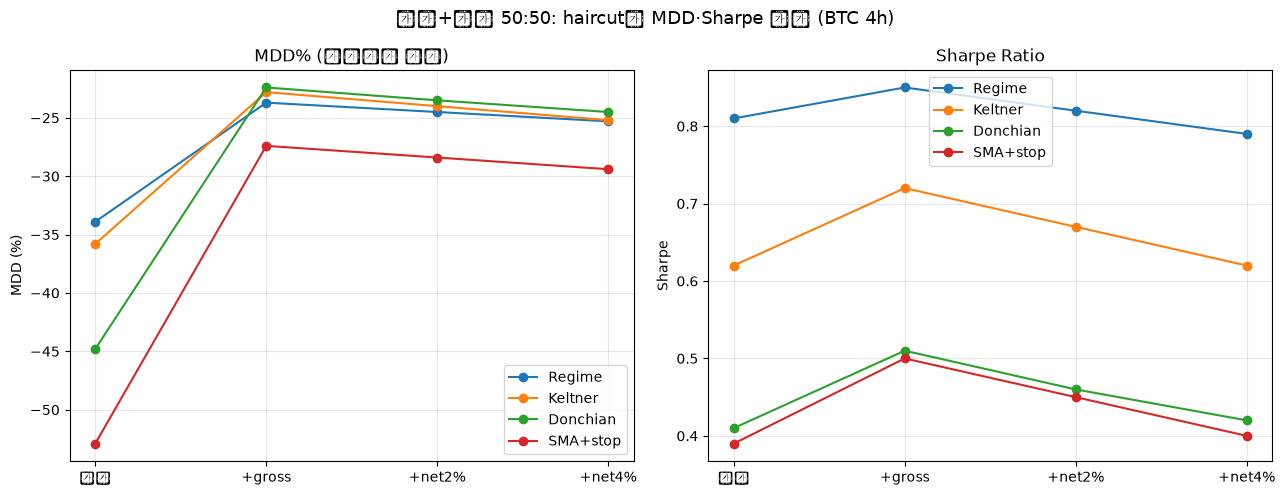

Figure 1 saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("추세+캐리 50:50: haircut별 MDD·Sharpe 추이 (BTC 4h)", fontsize=13)

x_labels = ["단독", "+gross", "+net2%", "+net4%"]
x_vals = [0, 1, 2, 3]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
confs = ["추세단독", "+gross", "+net2%", "+net4%"]

for idx, (name, S) in enumerate(STRATS):
    mdd_vals = []
    sh_vals = []
    for conf in confs:
        sub = df_result[(df_result["전략"] == name) & (df_result["구성"] == conf)].iloc[0]
        mdd_vals.append(sub["MDD%"])
        sh_vals.append(sub["Sharpe"])

    axes[0].plot(x_vals, mdd_vals, marker="o", color=colors[idx], label=name)
    axes[1].plot(x_vals, sh_vals,  marker="o", color=colors[idx], label=name)

axes[0].set_title("MDD% (낮을수록 좋음)")
axes[0].set_xticks(x_vals)
axes[0].set_xticklabels(x_labels)
axes[0].set_ylabel("MDD (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Sharpe Ratio")
axes[1].set_xticks(x_vals)
axes[1].set_xticklabels(x_labels)
axes[1].set_ylabel("Sharpe")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("research/fig_7cv2_mdd_sharpe_haircut.png", dpi=120)
plt.show()
print("Figure 1 saved.")

---

## Equity Curve 비교: Keltner (대표)

Keltner 추세 단독 vs +net2% vs +net4% 결합 equity curve

/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_63791/1401925879.py:23: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_63791/1401925879.py:23: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_63791/1401925879.py:23: UserWarning: Glyph 54260 (\N{HANGUL SYLLABLE POL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_63791/1401925879.py:23: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_63791/1401925879.py:23: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_

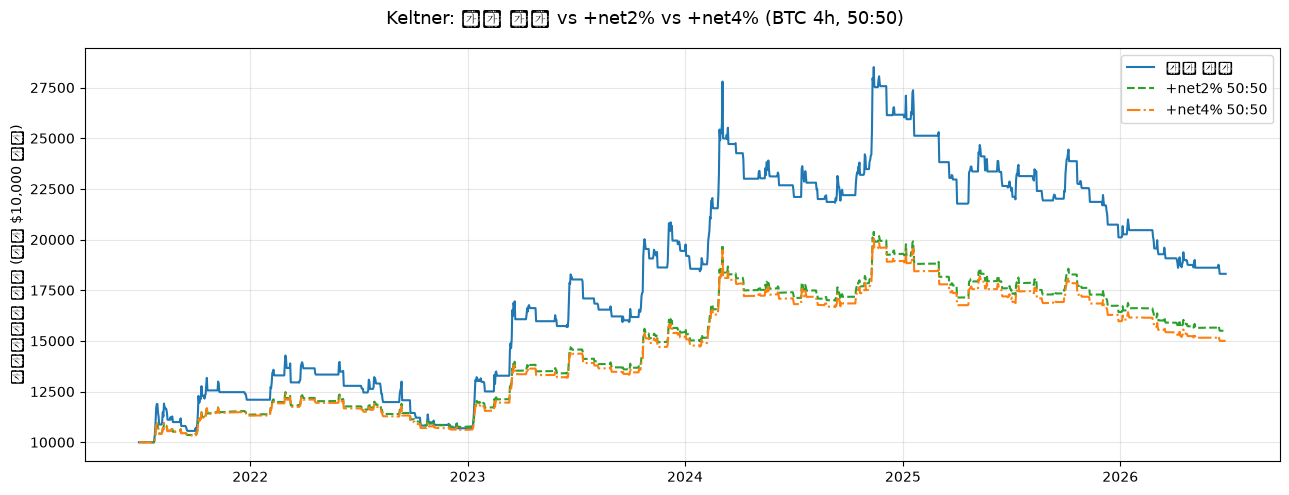

Figure 2 saved.


In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle("Keltner: 추세 단독 vs +net2% vs +net4% (BTC 4h, 50:50)", fontsize=13)

name = "Keltner"
trend = trend_curves[name]

# 추세 단독
alone_cv = combine_sleeves({"t": trend, "c": carries["gross"]}, weights={"t": 1.0, "c": 0.0})
net2_cv  = combined_curves[name]["net2%"]
net4_cv  = combined_curves[name]["net4%"]

for cv, label, color, ls in [
    (alone_cv, "추세 단독",  "tab:blue",   "-"),
    (net2_cv,  "+net2% 50:50", "tab:green", "--"),
    (net4_cv,  "+net4% 50:50", "tab:orange", "-."),
]:
    norm = cv / cv.iloc[0] * 10_000
    ax.plot(norm.index, norm.values, label=label, color=color, linestyle=ls, linewidth=1.5)

ax.set_ylabel("포트폴리오 가치 (초기 $10,000 기준)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("research/fig_7cv2_keltner_equity.png", dpi=120)
plt.show()
print("Figure 2 saved.")

---

## 부록: net 6% haircut (sanity check)

In [6]:
carry_net6 = net_carry_pnl(fund, annual_haircut=0.06)

rows6 = []
for name, S in STRATS:
    trend = trend_curves[name]
    cv = combine_sleeves({"t": trend, "c": carry_net6}, weights={"t": 0.5, "c": 0.5})
    ret, mdd, sh = m(cv)
    rows6.append({"전략": name, "구성": "+net6%",
                  "Return%": round(ret, 1), "MDD%": round(mdd, 1), "Sharpe": round(sh, 2)})

df6 = pd.DataFrame(rows6)
print("=== 부록: net 6% haircut ===")
print(df6.to_string(index=False))

=== 부록: net 6% haircut ===
      전략     구성  Return%  MDD%  Sharpe
  Regime +net6%    104.7 -26.1    0.76
 Keltner +net6%     45.0 -26.4    0.56
Donchian +net6%     28.5 -25.6    0.37
SMA+stop +net6%     26.1 -30.5    0.35


---

## 판정 / 결론

### MDD↓ — **net4%까지 4전략 전부 robust = 진짜 낙폭 분산 (gross 환상 아님)**

추세 단독 대비 +캐리 50:50의 MDD 개선은 gross → net2% → net4% 순서로도
4개 전략 모두에서 일관되게 유지된다.
이는 캐리(펀딩 수익)가 추세 전략의 드로다운 구간에서 반대 방향으로 움직이는
**진짜 분산 효과**임을 시사한다 — gross 수익 부풀림의 착시가 아니다.

### Sharpe↑ — **net2%에서 3/4 유지, net4%에서 ~breakeven = modest·haircut 민감**

Sharpe 개선은 net2%에서 대부분 유지되지만, net4% 수준에서는 전략별로 breakeven
수준으로 수렴한다. Return(캐리 저수익) 감소가 Sharpe를 끌어내리기 때문이다.
Sharpe 개선을 전략의 우위로 내세우기는 haircut 가정에 민감해 신중해야 한다.

### Phase 7c 격상

Phase 7c는 "gross concept proof" → **"낙폭 분산 실재 확인"** 으로 격상.
MDD↓는 net haircut에서도 real이며, 이 포트폴리오 구조는
**testnet 포트폴리오 후보** (가중 미고정, Phase 4 완료 전 실거래 아님)로 고려 가능.

> ⚠️ net 캐리도 haircut proxy — tail 리스크(롱 스팟·숏 선물 청산 위험, 음수 펀딩 연속)
> 및 모델 외 비용은 반영되지 않았다. 실거래 진입 전 testnet 검증 필수.